In [28]:
import numpy as np
from itertools import combinations
from math import comb
import numpy as np
import matplotlib.pyplot as plt


def finitechanges_shapley(x0, x1, model):
    """
    Finite-change decomposition with baseline Shapley allocation.

    Parameters
    ----------
    x0 : array-like
        Base-case input vector.

    x1 : array-like
        New input vector.

    model : callable
        Function y = model(x).

    Returns
    -------
    result : dict
        Dictionary containing:
        - U        : subset matrix
        - DX       : evaluated input points
        - y        : model evaluations
        - ff       : finite-change effects
        - phi      : total-order finite-change effects
        - Shap     : baseline Shapley values
        - combos   : list of subsets
        - y0       : base-case output
        - y1       : new output
        - dy       : total finite change
    """

    x0 = np.asarray(x0, dtype=float).reshape(-1)
    x1 = np.asarray(x1, dtype=float).reshape(-1)

    dx = x1 - x0
    n = len(x0)

    # Number of columns: all nonempty subsets + base case
    m = 2**n

    U = np.zeros((n, m), dtype=float)
    combos = []

    col = 0

    # Nonempty subsets, ordered by cardinality
    for l in range(1, n + 1):
        for combo in combinations(range(n), l):
            U[list(combo), col] = 1.0
            combos.append(combo)
            col += 1

    # Last column is the base case
    U[:, -1] = 0.0

    # Construct evaluated points
    DX = x0[:, None] + dx[:, None] * U

    # Model evaluations
    y = np.array(
        [model(DX[:, i]) for i in range(m)],
        dtype=float
    )

    y0 = y[-1]
    y1 = model(x1)
    dy = y1 - y0

    # Finite-change effects
    ff = np.zeros(m, dtype=float)

    k = 0

    for l in range(1, n + 1):

        b = comb(n, l)

        for i in range(k, k + b):

            ff[i] = y[i]

            # subtract all lower-order subset effects
            for u in range(k):

                is_subset = (
                    np.dot(U[:, i], U[:, u]) == np.sum(U[:, u])
                )

                if is_subset:
                    ff[i] -= ff[u]

            ff[i] -= y0

        k += b

    # Last column is the base case, so effect is zero
    ff[-1] = 0.0

    # Total-order effects
    phi = U @ ff

    # Baseline Shapley values
    Shap = np.zeros(n)

    for j in range(n):
        for i in range(m):

            card = np.sum(U[:, i])

            if card > 0 and U[j, i] == 1:
                Shap[j] += ff[i] / card

    result = {
        "U": U,
        "DX": DX,
        "y": y,
        "ff": ff[:-1],
        "phi": phi,
        "Shap": Shap,
        "combos": combos,
        "y0": y0,
        "y1": y1,
        "dy": dy
    }

    return result

In [29]:


# ==========================================================
# 1. Ishigami model
# ==========================================================

def model(x):
    """
    Ishigami function.

    y = sin(x1) + a sin^2(x2) + b x3^4 sin(x1)
    """

    x1, x2, x3 = x

    a = 7
    b = 0.1

    return (
        np.sin(x1)
        + a * np.sin(x2)**2
        + b * x3**4 * np.sin(x1)
    )


In [30]:
# ==========================================================
# 2. Define base case and changed point
# ==========================================================

x0 = np.array([1.0, 1.0, 1.0])
x1 = np.array([2.0, 2.0, 2.0])

variable_names = ["x1", "x2", "x3"]


# ==========================================================
# 3. Run finite-change decomposition with Shapley allocation
# ==========================================================

result = finitechanges_shapley(
    x0,
    x1,
    model
)


# ==========================================================
# 4. Print basic checks
# ==========================================================

print("Base-case output y0 =", result["y0"])
print("Changed output y1   =", result["y1"])
print("Total change Δy     =", result["dy"])
print()

print("Check: sum finite-change terms =", np.sum(result["ff"]))
print("Check: sum Shapley values      =", np.sum(result["Shap"]))

Base-case output y0 = 5.882132011203685
Changed output y1   = 8.151925982769415
Total change Δy     = 2.26979397156573

Check: sum finite-change terms = 2.26979397156573
Check: sum Shapley values      = 2.26979397156573


In [31]:
def plot_finitechange_decomposition(
    result,
    variable_names=None,
    sort_by="abs"
):

    ff = np.asarray(result["ff"], dtype=float)
    combos = result["combos"]

    n = len(result["Shap"])

    if variable_names is None:
        variable_names = [f"x{i+1}" for i in range(n)]

    labels = []

    for combo in combos:
        labels.append(
            ",".join(variable_names[i] for i in combo)
        )

    if sort_by == "abs":
        idx = np.argsort(np.abs(ff))[::-1]
    else:
        idx = np.arange(len(ff))

    ff = ff[idx]
    labels = [labels[i] for i in idx]

    y = np.arange(len(labels))

    plt.figure(figsize=(9,5))

    plt.barh(
        y,
        ff,
        color="steelblue"
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1.5
    )

    plt.yticks(y, labels)

    plt.xlabel("Finite-change contribution")
    plt.title("Finite-Change Decomposition")

    plt.gca().invert_yaxis()

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

In [32]:
def print_shapley_summary(result, variable_names=None):

    n = len(result["Shap"])

    if variable_names is None:
        variable_names = [f"x{i+1}" for i in range(n)]

    print("Finite-change decomposition")
    print("---------------------------")
    print(f"y0 = {result['y0']:.6f}")
    print(f"y1 = {result['y1']:.6f}")
    print(f"Δy = {result['dy']:.6f}")
    print()

    print("All finite-change terms")
    print("-----------------------")

    for combo, value in zip(result["combos"], result["ff"]):

        label = ",".join(variable_names[i] for i in combo)

        print(f"{label:>10s} : {value: .6f}")

    print()
    print("Baseline Shapley values")
    print("-----------------------")

    for name, value in zip(variable_names, result["Shap"]):
        print(f"{name:>10s} : {value: .6f}")

    print()
    print(f"Sum finite-change terms = {np.sum(result['ff']): .6f}")
    print(f"Sum Shapley values      = {np.sum(result['Shap']): .6f}")

In [33]:
def plot_baseline_shapley(
    result,
    variable_names=None
):

    shap = np.asarray(result["Shap"])

    n = len(shap)

    if variable_names is None:
        variable_names = [
            f"x{i+1}"
            for i in range(n)
        ]

    idx = np.argsort(np.abs(shap))[::-1]

    shap = shap[idx]
    names = [variable_names[i] for i in idx]

    y = np.arange(n)

    plt.figure(figsize=(8,4))

    plt.barh(
        y,
        shap,
        color="darkgreen"
    )

    plt.axvline(
        0,
        color="black",
        linewidth=1.5
    )

    plt.yticks(y, names)

    plt.xlabel("Baseline Shapley value")
    plt.title("Baseline Shapley Allocation")

    plt.gca().invert_yaxis()

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.35
    )

    plt.tight_layout()
    plt.show()

Finite-change decomposition
---------------------------
y0 = 5.882132
y1 = 8.151926
Δy = 2.269794

All finite-change terms
-----------------------
        x1 :  0.074609
        x2 :  0.831239
        x3 :  1.262206
     x1,x2 :  0.000000
     x1,x3 :  0.101740
     x2,x3 :  0.000000
  x1,x2,x3 :  0.000000

Baseline Shapley values
-----------------------
        x1 :  0.125479
        x2 :  0.831239
        x3 :  1.313076

Sum finite-change terms =  2.269794
Sum Shapley values      =  2.269794


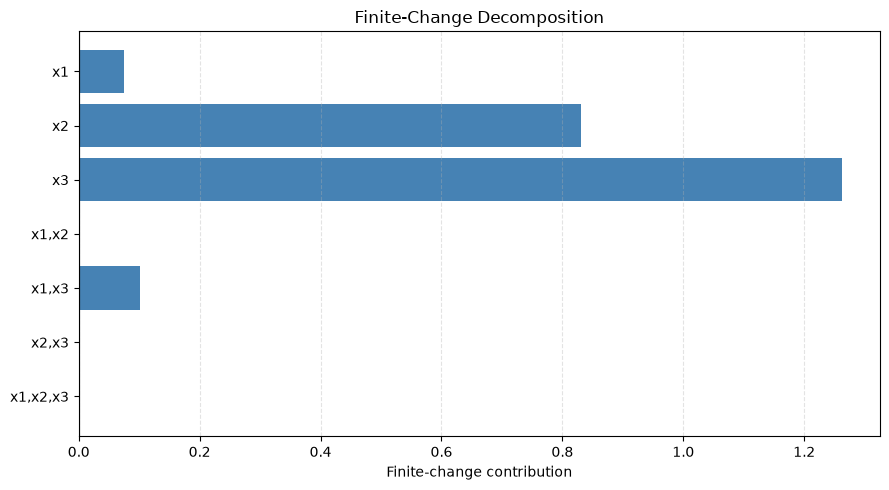

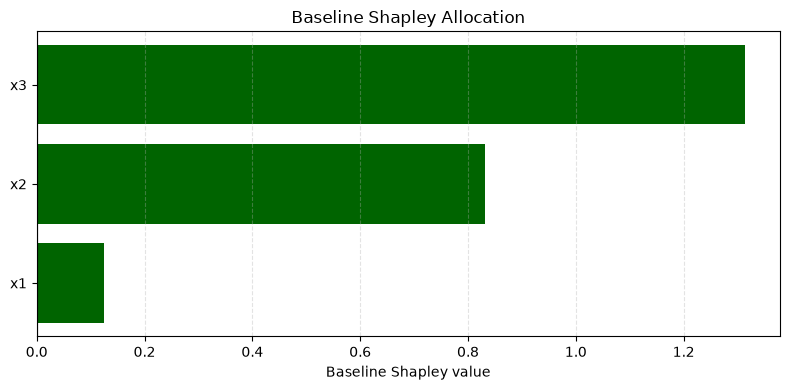

In [34]:
x0 = np.array([1.0, 1.0, 1.0])
x1 = np.array([2.0, 2.0, 2.0])

variable_names = ["x1", "x2", "x3"]

result = finitechanges_shapley(
    x0,
    x1,
    model
)

print_shapley_summary(
    result,
    variable_names
)

plot_finitechange_decomposition(
    result,
    variable_names,
    sort_by="order"
)

plot_baseline_shapley(
    result,
    variable_names
)